In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skewnorm, skew
import os
from utils.generate_points import generate_skewed_coordinates_and_save,generate_normal_coordinates

Success: 1000 points saved to 'datasets/normal_coords_1.csv'.
Success: 1000 points saved to 'datasets/normal_coords_2.csv'.
Success: 1000 points saved to 'datasets/normal_coords_3.csv'.
Success: 1000 points saved to 'datasets/normal_coords_4.csv'.


Generating Datasets...
 -> Dataset 1 generated and saved to datasets/normal_coords_1.csv
 -> Dataset 2 generated and saved to datasets/normal_coords_2.csv
 -> Dataset 3 generated and saved to datasets/normal_coords_3.csv
 -> Dataset 4 generated and saved to datasets/normal_coords_4.csv
Saved 'spatial_quadrants.png'


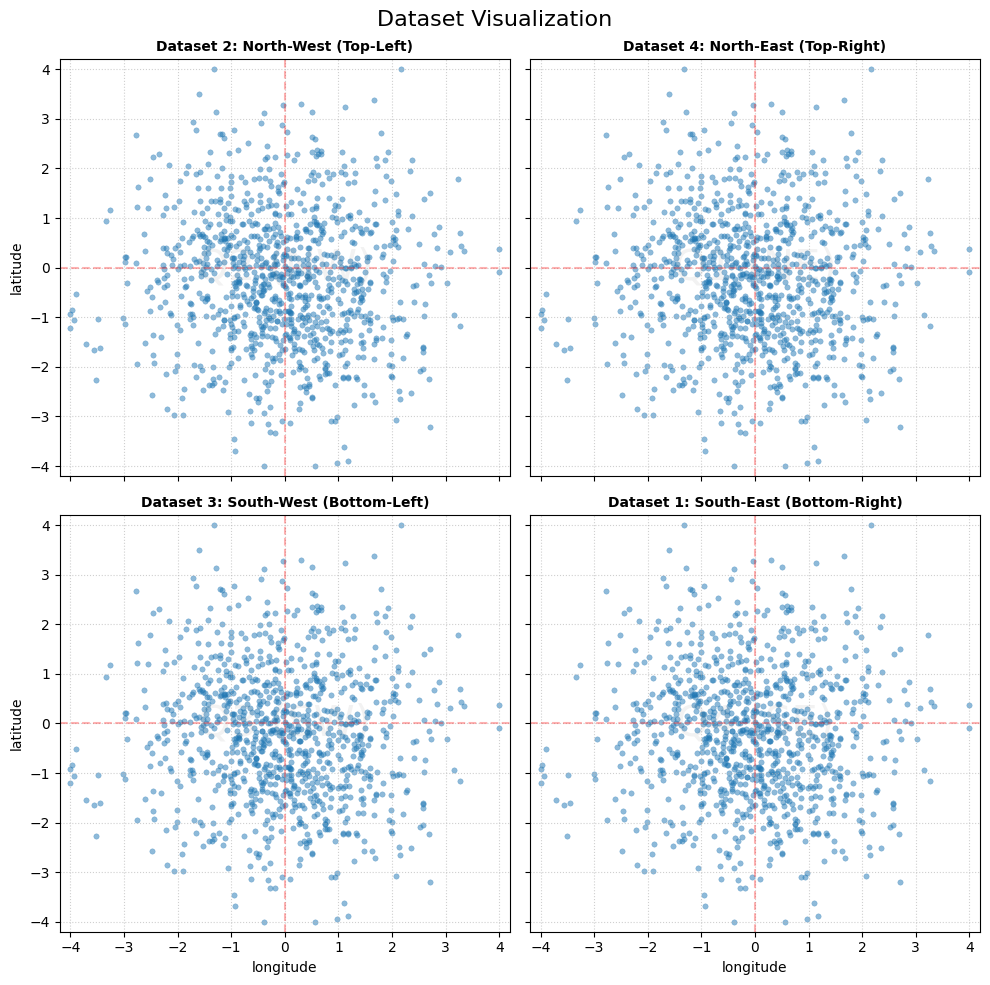

Saved 'density_histograms.png'


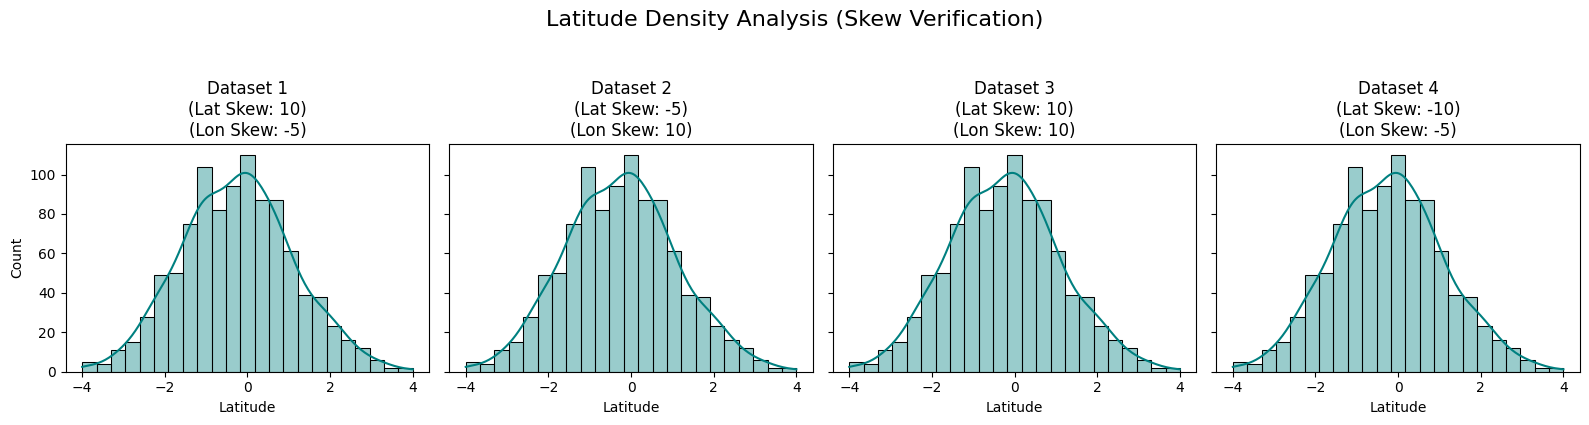


--- DATASET DESCRIPTION TABLE (For your Report) ---
|   Dataset |   N Points |   Measured Lat Skew |   Measured Lon Skew | Lat Range   | Lon Range   |
|----------:|-----------:|--------------------:|--------------------:|:------------|:------------|
|         1 |       1000 |                 0.1 |               -0.05 | -4.0 to 4.0 | -4.0 to 4.0 |
|         2 |       1000 |                 0.1 |               -0.05 | -4.0 to 4.0 | -4.0 to 4.0 |
|         3 |       1000 |                 0.1 |               -0.05 | -4.0 to 4.0 | -4.0 to 4.0 |
|         4 |       1000 |                 0.1 |               -0.05 | -4.0 to 4.0 | -4.0 to 4.0 |

--- EXECUTION SIMULATION ---
Now run your overlap/clustering algorithm on these files:
1. datasets/skewed_coords_1.csv
2. datasets/skewed_coords_2.csv
3. datasets/skewed_coords_3.csv
4. datasets/skewed_coords_4.csv


In [2]:
# --- 1. The Improved Generator Function ---
# def generate_skewed_coordinates(
#     num_points: int,
#     latitude_skew: float,
#     longitude_skew: float,
#     lat_min: float = -4.0,
#     lat_max: float = 4.0,
#     lon_min: float = -4.0,
#     lon_max: float = 4.0,
#     random_seed: int = None,
#     outlier_clip_percentile: float = 99.9,
# ):
#     if num_points <= 0:
#         return None

#     if random_seed is not None:
#         np.random.seed(random_seed)

#     # Generate Raw Skewed Data
#     latitudes_raw = skewnorm.rvs(a=latitude_skew, size=num_points)
#     longitudes_raw = skewnorm.rvs(a=longitude_skew, size=num_points)

#     # Clip outliers to stabilize the map boundaries
#     lat_lower = np.percentile(latitudes_raw, 100 - outlier_clip_percentile)
#     lat_upper = np.percentile(latitudes_raw, outlier_clip_percentile)
#     lon_lower = np.percentile(longitudes_raw, 100 - outlier_clip_percentile)
#     lon_upper = np.percentile(longitudes_raw, outlier_clip_percentile)

#     latitudes_raw = np.clip(latitudes_raw, lat_lower, lat_upper)
#     longitudes_raw = np.clip(longitudes_raw, lon_lower, lon_upper)

#     # Normalize to 0-1
#     lat_norm = (latitudes_raw - latitudes_raw.min()) / (
#         latitudes_raw.max() - latitudes_raw.min()
#     )
#     lon_norm = (longitudes_raw - longitudes_raw.min()) / (
#         longitudes_raw.max() - longitudes_raw.min()
#     )

#     # Scale to bounds
#     latitudes = lat_min + lat_norm * (lat_max - lat_min)
#     longitudes = lon_min + lon_norm * (lon_max - lon_min)

#     return pd.DataFrame({"latitude": latitudes, "longitude": longitudes})


# --- 2. Generate the 4 Controlled Datasets (1, 2, 3, 4) ---
datasets_config = [
    # (Name, Lat Skew, Lon Skew, Title)
    ("1", 10, -5, "Dataset 1: South-East (Bottom-Right)"),
    ("2", -5, 10, "Dataset 2: North-West (Top-Left)"),
    ("3", 10, 10, "Dataset 3: South-West (Bottom-Left)"),
    ("4", -10, -5, "Dataset 4: North-East (Top-Right)"),
]

data_storage = {}

print("Generating Datasets...")
for name, lat_s, lon_s, title in datasets_config:
    # Generate
    df = generate_normal_coordinates(
        num_points=1000,
        save_file=False,
        random_seed=42,
    )
    # df = generate_skewed_coordinates_and_save(
    #     1000, lat_s, lon_s, random_seed=42, save_file=False
    # )
    df["dataset_id"] = name

    # Store
    data_storage[name] = df

    # Save
    filename = f"datasets/normal_coords_{name}.csv"
    # Ensure directory exists (optional, but good practice)

    os.makedirs("datasets", exist_ok=True)

    df.to_csv(filename, index=False)
    print(f" -> Dataset {name} generated and saved to {filename}")


# --- 3. Visualization: Geographic Distribution (Scatter) ---
fig1, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
fig1.suptitle("Dataset Visualization", fontsize=16, y=0.98)

# MAPPING LOGIC:.
# (0,0)=TopLeft, (0,1)=TopRight, (1,0)=BottomLeft, (1,1)=BottomRight
plot_mapping = [
    {"pos": (0, 0), "id": "2", "bg_text": "Q2 (NW)"},  # Dataset 2 is North-West
    {"pos": (0, 1), "id": "4", "bg_text": "Q1 (NE)"},  # Dataset 4 is North-East
    {"pos": (1, 0), "id": "3", "bg_text": "Q3 (SW)"},  # Dataset 3 is South-West
    {"pos": (1, 1), "id": "1", "bg_text": "Q4 (SE)"},  # Dataset 1 is South-East
]

for item in plot_mapping:
    # Retrieve data based on ID
    dataset_id = item["id"]
    pos = item["pos"]
    df = data_storage[dataset_id]

    # Find the full title from config
    title = next(cfg[3] for cfg in datasets_config if cfg[0] == dataset_id)

    ax = axes[pos]

    # Scatter Plot
    sns.scatterplot(
        data=df, x="longitude", y="latitude", ax=ax, alpha=0.5, s=15, edgecolor=None
    )

    # Styling
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlim(-4.2, 4.2)
    ax.set_ylim(-4.2, 4.2)
    ax.grid(True, linestyle=":", alpha=0.6)

    # Quadrant Labels (Q1, Q2, etc.) background text
    ax.text(
        0,
        0,
        item["bg_text"],
        fontsize=30,
        color="grey",
        alpha=0.1,
        ha="center",
        va="center",
    )

    # Center Lines
    ax.axhline(0, color="red", linestyle="--", alpha=0.3)
    ax.axvline(0, color="red", linestyle="--", alpha=0.3)

plt.tight_layout()
fig1.savefig("spatial_quadrants.png", dpi=300, bbox_inches="tight")
print("Saved 'spatial_quadrants.png'")
plt.show()


# ==========================================
# PLOT 2: DENSITY DISTRIBUTION (Histograms)
# ==========================================
fig2, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig2.suptitle("Latitude Density Analysis (Skew Verification)", fontsize=16, y=1.05)

# Sort strictly by name "1", "2", "3", "4" for the linear histogram chart
sorted_configs = sorted(datasets_config, key=lambda x: x[0])

for i, (name, lat_s, lon_s, title) in enumerate(sorted_configs):
    df = data_storage[name]
    sns.histplot(df["latitude"], kde=True, ax=axes[i], color="teal", alpha=0.4)
    axes[i].set_title(f"Dataset {name}\n(Lat Skew: {lat_s})\n(Lon Skew: {lon_s})")
    axes[i].set_xlabel("Latitude")

plt.tight_layout()
fig2.savefig("density_histograms.png", dpi=300, bbox_inches="tight")
print("Saved 'density_histograms.png'")
plt.show()


# --- 5. Generate Metrics Table for Report ---
metrics_list = []

# Ensure we process in order 1, 2, 3, 4
for name in ["1", "2", "3", "4"]:
    df = data_storage[name]
    real_lat_skew = skew(df["latitude"])
    real_lon_skew = skew(df["longitude"])

    metrics_list.append(
        {
            "Dataset": name,
            "N Points": len(df),
            "Measured Lat Skew": round(real_lat_skew, 2),
            "Measured Lon Skew": round(real_lon_skew, 2),
            "Lat Range": f"{df['latitude'].min():.1f} to {df['latitude'].max():.1f}",
            "Lon Range": f"{df['longitude'].min():.1f} to {df['longitude'].max():.1f}",
        }
    )

metrics_df = pd.DataFrame(metrics_list)

print("\n--- DATASET DESCRIPTION TABLE (For your Report) ---")
try:
    print(metrics_df.to_markdown(index=False))
except ImportError:
    print(metrics_df)  # Fallback if tabulate is not installed

# --- 6. Execution Simulation ---
print("\n--- EXECUTION SIMULATION ---")
print("Now run your overlap/clustering algorithm on these files:")
print("1. datasets/skewed_coords_1.csv")
print("2. datasets/skewed_coords_2.csv")
print("3. datasets/skewed_coords_3.csv")
print("4. datasets/skewed_coords_4.csv")

Saved 'spatial_heatmaps.png'


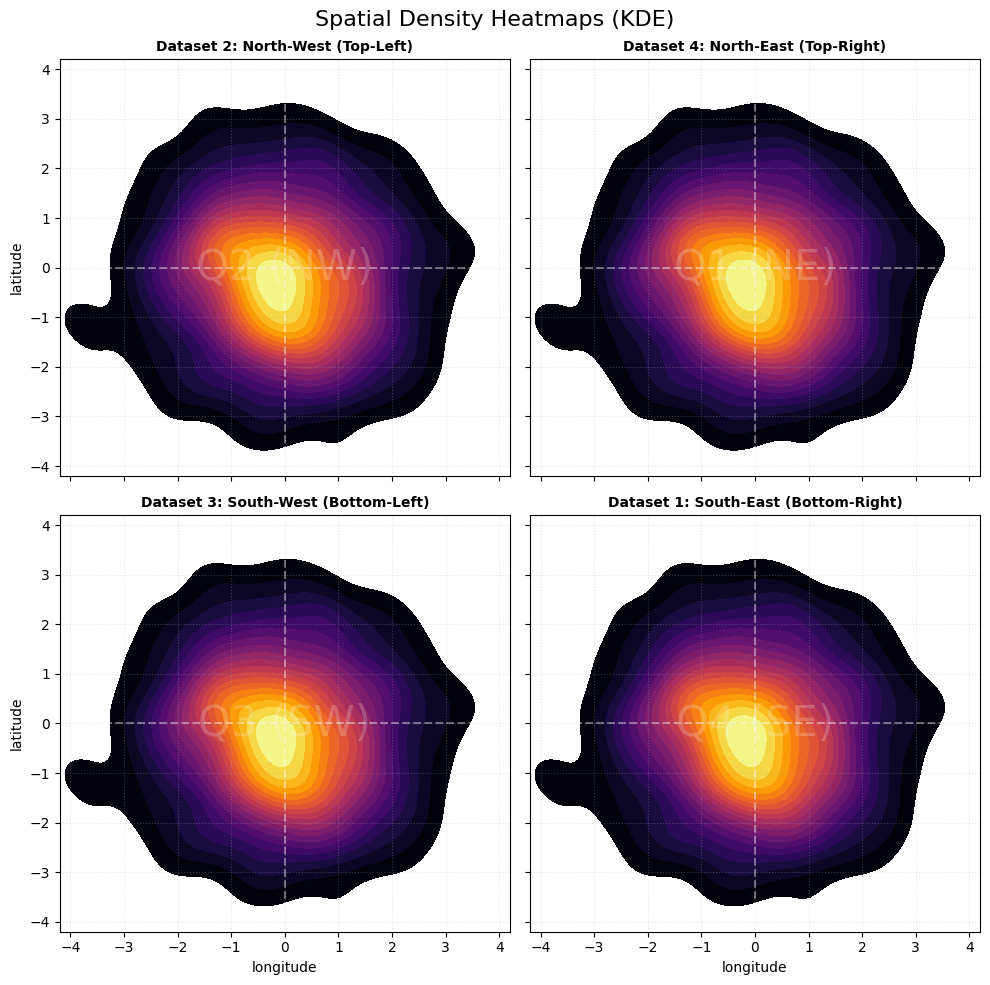

In [3]:
fig3, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
fig3.suptitle("Spatial Density Heatmaps (KDE)", fontsize=16, y=0.98)

for item in plot_mapping:
    dataset_id = item["id"]
    pos = item["pos"]
    df = data_storage[dataset_id]
    title = next(cfg[3] for cfg in datasets_config if cfg[0] == dataset_id)

    ax = axes[pos]
    
    # Kernel Density Estimate (Heatmap)
    # fill=True creates the heatmap effect
    # thresh=0.05 hides the very lowest density (background noise)
    sns.kdeplot(
        data=df, x="longitude", y="latitude", 
        ax=ax, fill=True, cmap="inferno", 
        levels=20, thresh=0.05
    )

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlim(-4.2, 4.2)
    ax.set_ylim(-4.2, 4.2)
    ax.grid(True, linestyle=":", alpha=0.3)
    
    # Add labels (White looks better on dark heatmap backgrounds)
    ax.text(0, 0, item["bg_text"], fontsize=30, color="white", alpha=0.2, ha="center", va="center")
    ax.axhline(0, color="white", linestyle="--", alpha=0.4)
    ax.axvline(0, color="white", linestyle="--", alpha=0.4)

plt.tight_layout()
fig3.savefig("spatial_heatmaps.png", dpi=300, bbox_inches="tight")
print("Saved 'spatial_heatmaps.png'")
plt.show()